<a href="https://colab.research.google.com/github/Anky597/Anky597/blob/main/Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
!pip install lime
!pip install shap

import lime
import shap


df = pd.read_csv('/content/loan_approval_dataset.csv')

# Display basic information about the dataset
print(df.info())
print(df.head())


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=68d1a32392a32664e65e19c0066a34dd6bb07d74ca7d5167ca897c6d416eaed7
  Stored in directory: /root/.cache/pip/wheels/fd/a2/af/9ac0a1a85a27f314a06b39e1f492bee1547d52549a4606ed89
Successfully built lime
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.1/540.1 kB 10.1 MB/s eta 0:00:00
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount       

In [2]:
# Check the column names to confirm the actual names
print(df.columns)


Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')


In [3]:
# Strip any leading/trailing spaces in column names
df.columns = df.columns.str.strip()

# Check the cleaned column names again
print(df.columns)


Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')


In [4]:
# Check for duplicates in the dataset
duplicates = df.duplicated()

# Count the number of duplicate rows
print(f"Number of duplicate rows: {duplicates.sum()}")

# If there are duplicates, remove them
if duplicates.sum() > 0:
    df = df.drop_duplicates()
    print("Duplicate rows removed.")


Number of duplicate rows: 0


In [5]:
# Check for null values in each column
null_values = df.isnull().sum()

print("Missing values in each column:\n", null_values)


df_cleaned = df.dropna()


df_filled = df.fillna({
    'no_of_dependents': df['no_of_dependents'].median(),
    'loan_amount': df['loan_amount'].mean(),


})


print(df_cleaned.info())
# OR
print(df_filled.info())


Missing values in each column:
 loan_id                     0
no_of_dependents            0
education                   0
self_employed               0
income_annum                0
loan_amount                 0
loan_term                   0
cibil_score                 0
residential_assets_value    0
commercial_assets_value     0
luxury_assets_value         0
bank_asset_value            0
loan_status                 0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term            

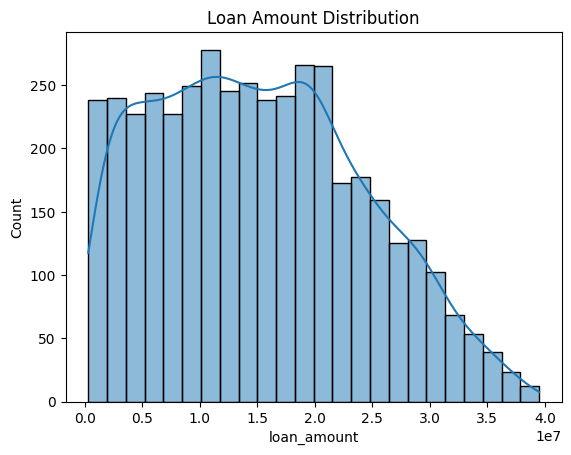

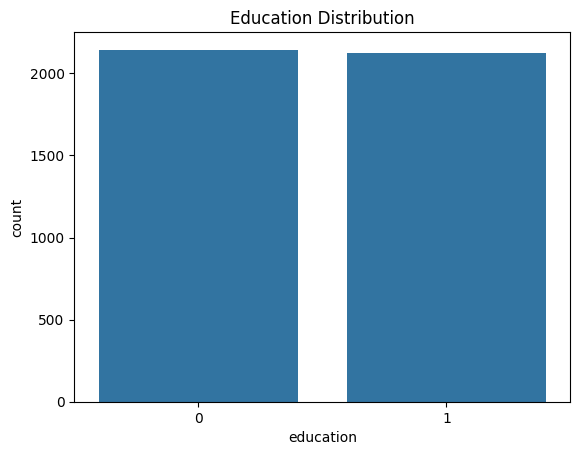

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot histogram for a numeric feature
sns.histplot(data=df, x='loan_amount', kde=True)
plt.title('Loan Amount Distribution')
plt.show()

# Bar plot for a categorical feature
sns.countplot(data=df, x='education')
plt.title('Education Distribution')
plt.show()


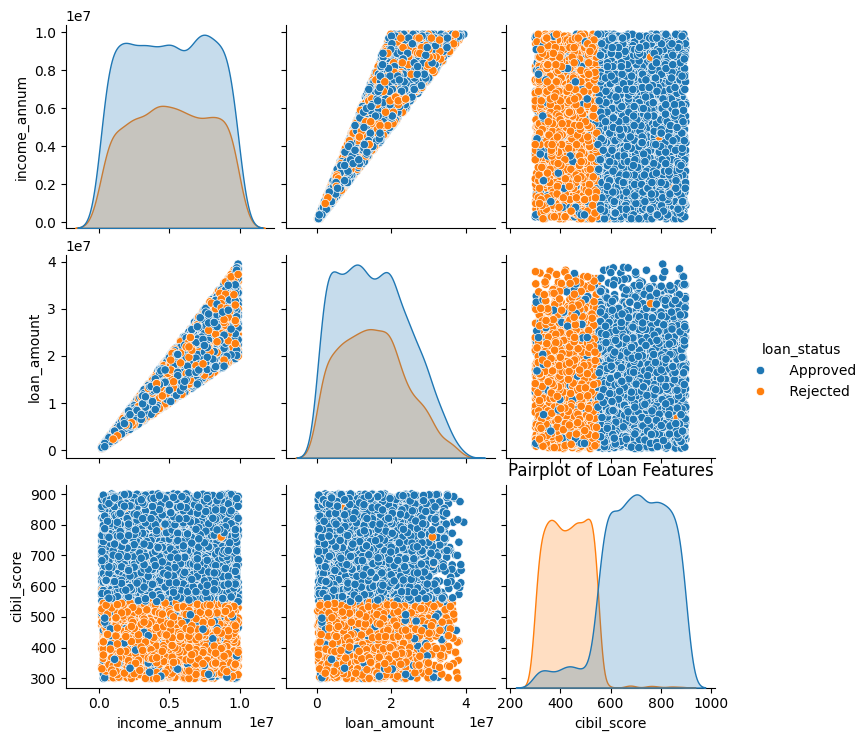

In [14]:
sns.pairplot(df[['income_annum', 'loan_amount', 'cibil_score', 'loan_status']], hue='loan_status')
plt.title('Pairplot of Loan Features')
plt.show()


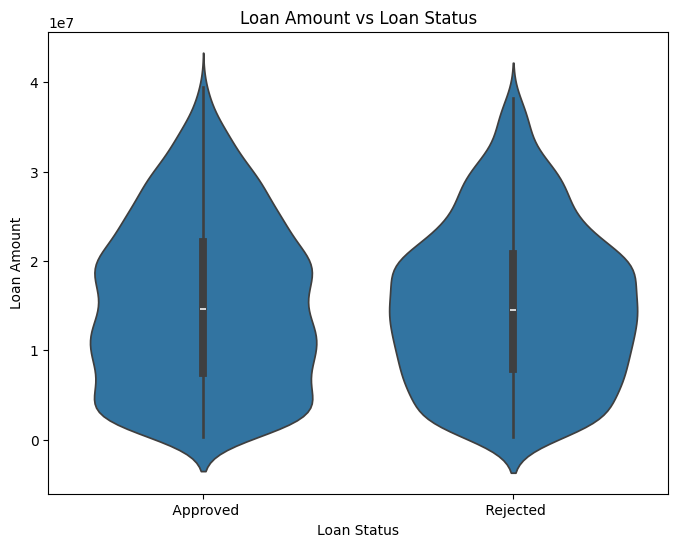

In [29]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='loan_status', y='loan_amount', data=df)
plt.title('Loan Amount vs Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Loan Amount')
plt.show()


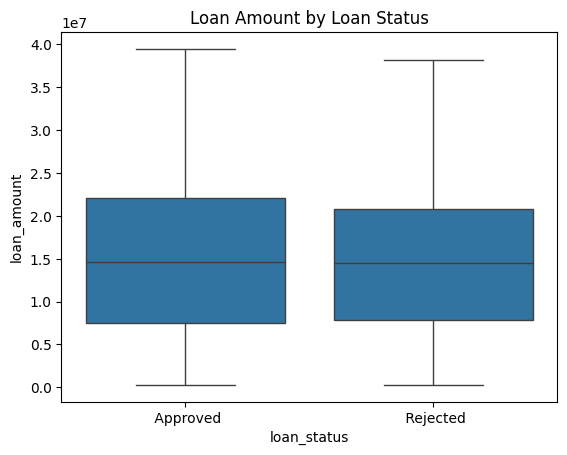

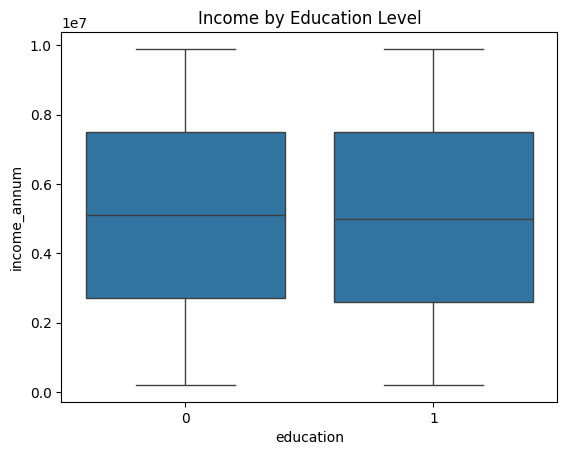

In [16]:

sns.boxplot(x='loan_status', y='loan_amount', data=df)
plt.title('Loan Amount by Loan Status')
plt.show()


sns.boxplot(x='education', y='income_annum', data=df)
plt.title('Income by Education Level')
plt.show()


In [6]:
pip install xgboost


In [7]:
# Data Preprocessing
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

df.columns = df.columns.str.strip()

# Encode categorical columns (education, self_employed)
le = LabelEncoder()
df['education'] = le.fit_transform(df['education'])
df['self_employed'] = le.fit_transform(df['self_employed'])

# Define X (features) and y (target)
X = df.drop(columns=['loan_id', 'loan_status'])  # Drop ID and target column
y = le.fit_transform(df['loan_status'])          # Encode target

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
}

# Dictionary to store model results
results = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"\nTraining and evaluating {name}...")

    # Train the model
    model.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = model.predict(X_test_scaled)

    # Calculate performance metrics
    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)

    # Store results
    results[name] = {
        'accuracy': accuracy,
        'confusion_matrix': conf_matrix,
        'classification_report': class_report
    }

    # Print results
    print(f"Accuracy: {accuracy * 100:.2f}%")
    print



Training and evaluating Logistic Regression...
Accuracy: 90.52%

Training and evaluating Random Forest...
Accuracy: 97.78%

Training and evaluating XGBoost...


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [14:20:20] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy: 98.24%


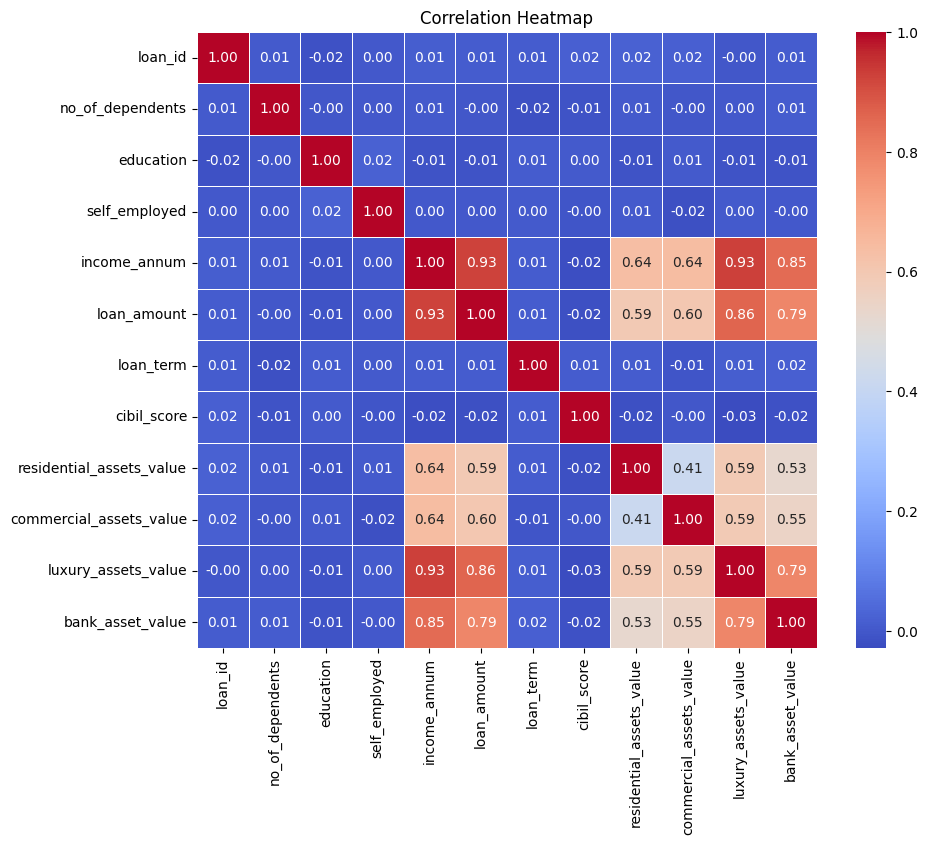

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns for correlation matrix
numeric_df = df.select_dtypes(include=['number'])


corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


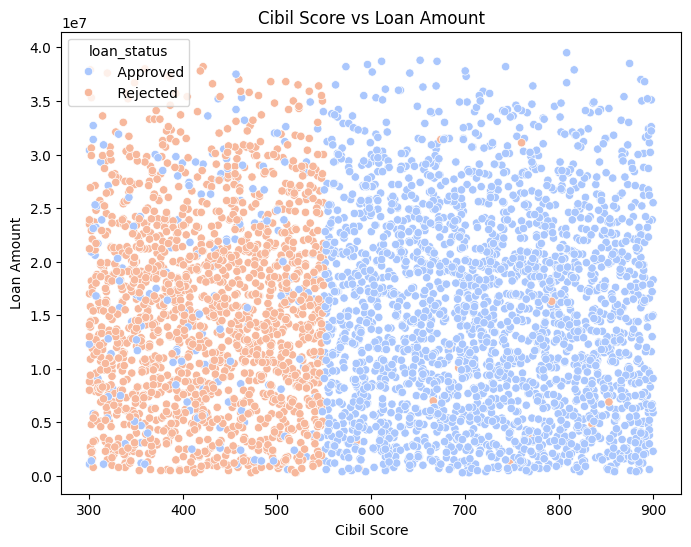

In [30]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='cibil_score', y='loan_amount', hue='loan_status', data=df, palette='coolwarm')
plt.title('Cibil Score vs Loan Amount')
plt.xlabel('Cibil Score')
plt.ylabel('Loan Amount')
plt.show()


In [21]:
import numpy as np

# Ensure features and importances have the same length
importances = model.feature_importances_
features = df.drop('loan_status', axis=1).columns


if len(importances) == len(features):
    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances, y=features)
    plt.title('Feature Importance')
    plt.show()
else:

    print(f"Length mismatch: Importances length = {len(importances)}, Features length = {len(features)}")


Length mismatch: Importances length = 11, Features length = 12


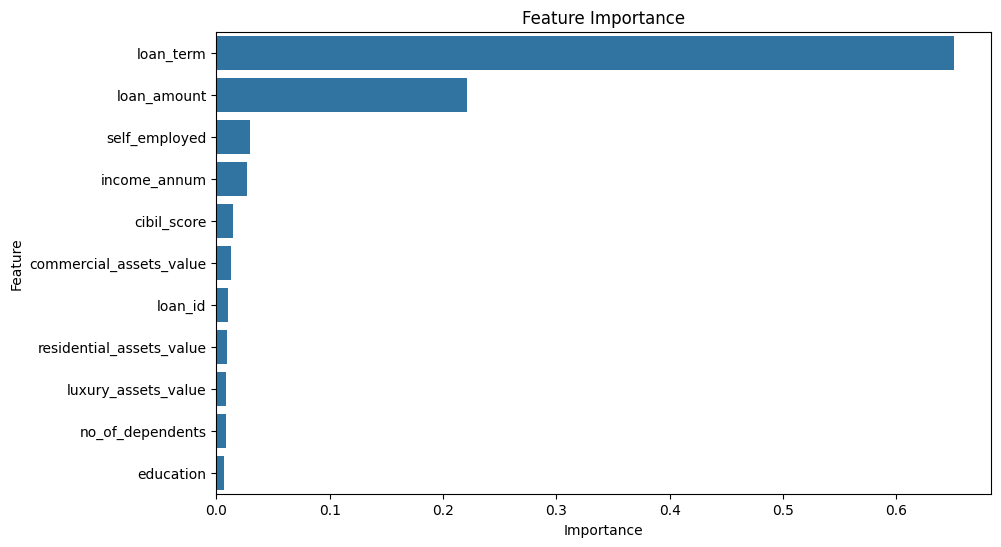

Feature Importances:
                      Feature  Importance
6                  loan_term    0.651389
5                loan_amount    0.221353
3              self_employed    0.030046
4               income_annum    0.026626
7                cibil_score    0.014356
9    commercial_assets_value    0.012546
0                    loan_id    0.010079
8   residential_assets_value    0.009585
10       luxury_assets_value    0.008647
1           no_of_dependents    0.008636
2                  education    0.006736


In [22]:
import pandas as pd


importances = model.feature_importances_
features = df.drop('loan_status', axis=1).columns


if len(importances) == len(features):
    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances, y=features)
    plt.title('Feature Importance')
    plt.show()
else:

    feature_importances_df = pd.DataFrame({
        'Feature': features[:len(importances)],
        'Importance': importances
    })


    feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)


    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importances_df)
    plt.title('Feature Importance')
    plt.show()

    print("Feature Importances:\n", feature_importances_df)


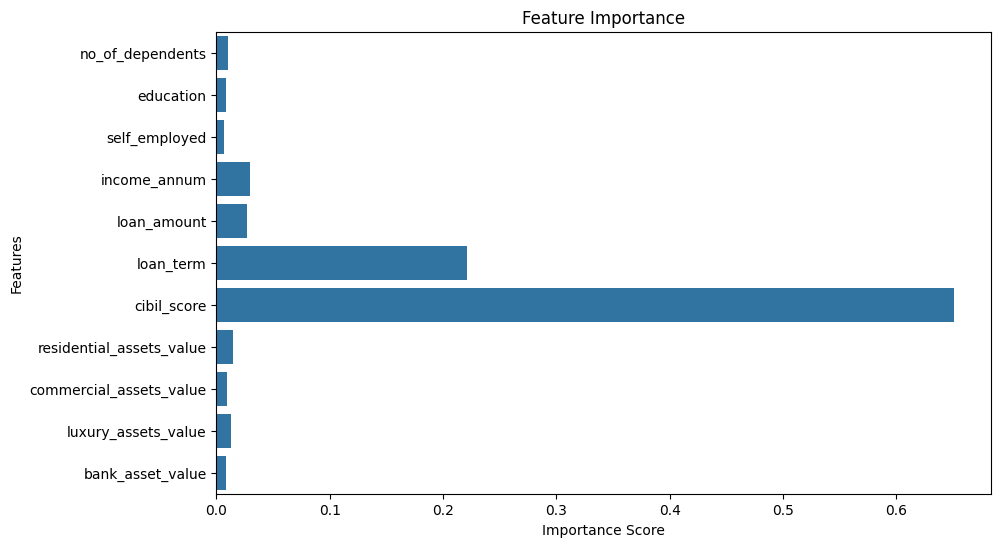

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = models['XGBoost'].feature_importances_
features = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=features)
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()


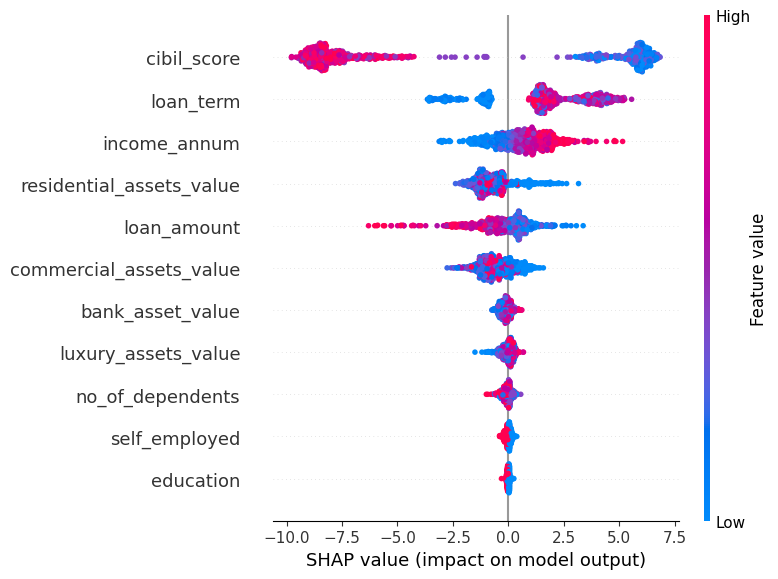

In [25]:
import shap

# Initialize SHAP explainer for the best model (XGBoost in this case)
explainer = shap.Explainer(models['XGBoost'])


shap_values = explainer(X_test_scaled)


shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)


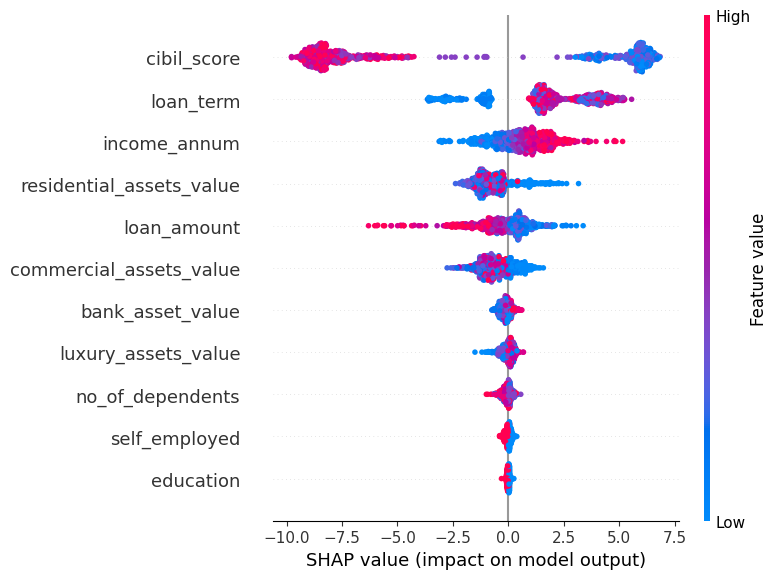

In [9]:
import shap


explainer = shap.Explainer(models['XGBoost'])


shap_values = explainer(X_test_scaled)

shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)


In [32]:
import lime
import lime.lime_tabular

# Initialize LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_scaled,
    feature_names=X.columns,
    class_names=['Rejected', 'Approved'],
    mode='classification'
)

# Choose a sample from the test set to explain (e.g., index 0)
sample_index = 1
sample = X_test_scaled[sample_index].reshape(1, -1)

# Explain the prediction for this specific sample
exp = explainer.explain_instance(sample[0], models['XGBoost'].predict_proba)

# Display explanation
exp.show_in_notebook(show_table=True, show_all=False)


In [33]:
import lime
import lime.lime_tabular

# Initialize LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_scaled,
    feature_names=X.columns,
    class_names=['Rejected', 'Approved'],
    mode='classification'
)

# Choose a sample from the test set to explain (e.g., index 0)
sample_index = 0
sample = X_test_scaled[sample_index].reshape(1, -1)

# Explain the prediction for this specific sample
exp = explainer.explain_instance(sample[0], models['XGBoost'].predict_proba)

# Display explanation
exp.show_in_notebook(show_table=True, show_all=False)


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
}

# Dictionary to store model results
results = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"\nTraining and evaluating {name}...")

    # Train the model
    model.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = model.predict(X_test_scaled)

    # Calculate performance metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary')
    recall = recall_score(y_test, y_pred, average='binary')
    f1 = f1_score(y_test, y_pred, average='binary')
    conf_matrix = confusion_matrix(y_test, y_pred)

    # Store results
    results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': conf_matrix,
        'classification_report': classification_report(y_test, y_pred)
    }

    # Print results
    print(f"Accuracy: {accuracy * 100:.2f}%")
    print(f"Precision: {precision * 100:.2f}%")
    print(f"Recall: {recall * 100:.2f}%")
    print(f"F1 Score: {f1 * 100:.2f}%")
    print("Confusion Matrix:\n", conf_matrix)
    print("\nClassification Report:\n", results[name]['classification_report'])

# Find the best model based on F1 Score (or accuracy if preferred)
best_model_name = max(results, key=lambda x: results[x]['f1_score'])
best_model_results = results[best_model_name]

print(f"\nBest Model based on F1 Score: {best_model_name}")
print(f"Best Model F1 Score: {best_model_results['f1_score'] * 100:.2f}%")
print(f"Best Model Accuracy: {best_model_results['accuracy'] * 100:.2f}%")



Training and evaluating Logistic Regression...
Accuracy: 90.52%
Precision: 87.86%
Recall: 86.48%
F1 Score: 87.16%
Confusion Matrix:
 [[498  38]
 [ 43 275]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.93      0.92       536
           1       0.88      0.86      0.87       318

    accuracy                           0.91       854
   macro avg       0.90      0.90      0.90       854
weighted avg       0.90      0.91      0.90       854


Training and evaluating Random Forest...
Accuracy: 97.78%
Precision: 97.76%
Recall: 96.23%
F1 Score: 96.99%
Confusion Matrix:
 [[529   7]
 [ 12 306]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98       536
           1       0.98      0.96      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.98       854
weighted avg       0.98      0.98      0.98

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [14:20:44] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [14]:
# prompt: give code to make a prediction from input

# Get input values for prediction
applicant_income = float(input("Enter applicant income: "))
coapplicant_income = float(input("Enter coapplicant income: "))
loan_amount = float(input("Enter loan amount: "))
loan_amount_term = float(input("Enter loan amount term: "))
credit_history = float(input("Enter credit history: "))
gender = int(input("Enter gender (0 for Male, 1 for Female): "))
married = int(input("Enter marital status (0 for No, 1 for Yes): "))
dependents = float(input("Enter number of dependents: "))
education = int(input("Enter education level (0 for Not Graduate, 1 for Graduate): "))
self_employed = int(input("Enter self-employed status (0 for No, 1 for Yes): "))
property_area = int(input("Enter property area (0 for Rural, 1 for Semiurban, 2 for Urban): "))

# Create a numpy array with the input values
input_data = np.array([[applicant_income, coapplicant_income, loan_amount, loan_amount_term,
                         credit_history, gender, married, dependents, education, self_employed, property_area]])

# Scale the input data using the same scaler used for training
input_data_scaled = scaler.transform(input_data)

# Make prediction using the best model (replace with your best model)
prediction = models['XGBoost'].predict(input_data_scaled)

# Print the prediction
if prediction[0] == 1:
  print("Loan Approved")
else:
  print("Loan Rejected")


Enter applicant income: 1
Enter coapplicant income: 0
Enter loan amount: 23000000
Enter loan amount term: 1
Enter credit history: 1
Enter gender (0 for Male, 1 for Female): 1
Enter marital status (0 for No, 1 for Yes): 1
Enter number of dependents: 23
Enter education level (0 for Not Graduate, 1 for Graduate): 0
Enter self-employed status (0 for No, 1 for Yes): 0
Enter property area (0 for Rural, 1 for Semiurban, 2 for Urban): 0
Loan Rejected


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [12]:
import pickle
best_model = models['XGBoost']
with open('best_model.pkl', 'wb') as model_file:
    pickle.dump(best_model, model_file)

print("Model saved successfully using pickle!")


Model saved successfully using pickle!


In [20]:
import joblib
from sklearn.preprocessing import StandardScaler

# Fit and transform your scaler on the training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Save the scaler to a file
joblib.dump(scaler, 'scaler.pkl')

print("Scaler saved successfully!")


Scaler saved successfully!


In [21]:
import pickle
from sklearn.preprocessing import StandardScaler

# Fit the scaler
scaler = StandardScaler().fit(X_train)

# Save the scaler using pickle
with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)


In [23]:
import pickle
from sklearn.preprocessing import StandardScaler

# Assuming you used StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)  # Fit scaler on your training data

# Save the scaler
with open('scaler2.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)
